In [1]:
import pandas as pd

# Load the dataset. Numbers use a comma as the decimal separator.
df = pd.read_csv("countries of the world.csv", decimal=",")

# Strip whitespace from the text columns.
df["Country"] = df["Country"].str.strip()
df["Region"] = df["Region"].str.strip()

print("Shape:", df.shape)
df.head()

Shape: (227, 20)


,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

In [3]:
gdp = df["GDP ($ per capita)"]

# 1. Non-missing count and missing count
print("Non-missing values:", gdp.count())
print("Missing values:    ", gdp.isna().sum())

# 2. Mean, median, standard deviation
print("\nMean:  ", round(gdp.mean(), 2))
print("Median:", round(gdp.median(), 2))
print("Std:   ", round(gdp.std(), 2))

# 3. Quartiles
q = gdp.quantile([0.25, 0.50, 0.75])
print("\n25th percentile (Q1):", q[0.25])
print("50th percentile (Q2):", q[0.50])
print("75th percentile (Q3):", q[0.75])

Non-missing values: 226
Missing values:     1

Mean:   9689.82
Median: 5550.0
Std:    10049.14

25th percentile (Q1): 1900.0
50th percentile (Q2): 5550.0
75th percentile (Q3): 15700.0


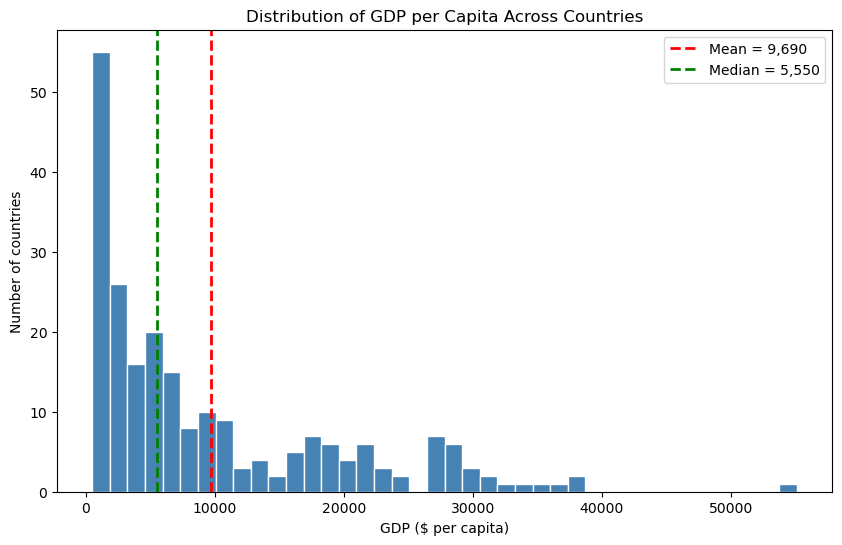

In [4]:
import matplotlib.pyplot as plt

gdp = df["GDP ($ per capita)"]
mean_gdp = gdp.mean()
median_gdp = gdp.median()

plt.figure(figsize=(10, 6))
plt.hist(gdp.dropna(), bins=40, color="steelblue", edgecolor="white")

plt.axvline(mean_gdp, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {mean_gdp:,.0f}")
plt.axvline(median_gdp, color="green", linestyle="--", linewidth=2,
            label=f"Median = {median_gdp:,.0f}")

plt.title("Distribution of GDP per Capita Across Countries")
plt.xlabel("GDP ($ per capita)")
plt.ylabel("Number of countries")
plt.legend()
plt.show()

In [5]:
gdp = df["GDP ($ per capita)"].dropna()
mean_gdp = gdp.mean()

below = (gdp < mean_gdp).sum()
above = (gdp > mean_gdp).sum()
pct_below = below / gdp.count() * 100

print(f"Mean GDP per capita: {mean_gdp:,.2f}")
print(f"Countries below the mean: {below}")
print(f"Countries above the mean: {above}")
print(f"Percentage below the mean: {pct_below:.1f}%")

Mean GDP per capita: 9,689.82
Countries below the mean: 149
Countries above the mean: 77
Percentage below the mean: 65.9%


Rows remaining: 223
Pearson correlation (r): 0.834


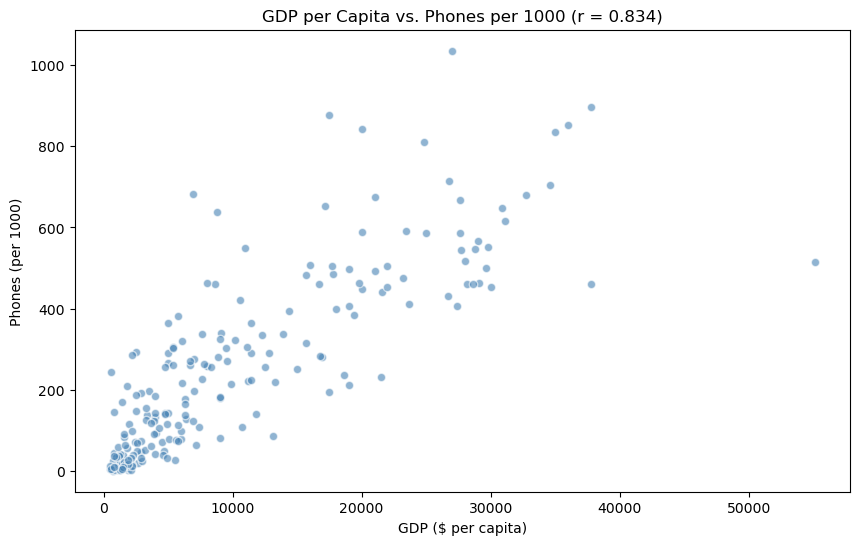

In [6]:
# Drop rows where either column is missing
pair = df[["GDP ($ per capita)", "Phones (per 1000)"]].dropna()
print("Rows remaining:", len(pair))

# Pearson correlation coefficient
r = pair["GDP ($ per capita)"].corr(pair["Phones (per 1000)"])
print(f"Pearson correlation (r): {r:.3f}")

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(pair["GDP ($ per capita)"], pair["Phones (per 1000)"],
            alpha=0.6, color="steelblue", edgecolor="white")
plt.title(f"GDP per Capita vs. Phones per 1000 (r = {r:.3f})")
plt.xlabel("GDP ($ per capita)")
plt.ylabel("Phones (per 1000)")
plt.show()

In [7]:
# Robustness check for the GDP vs Phones correlation
pair = df[["GDP ($ per capita)", "Phones (per 1000)"]].dropna()

# 1. Rows used
print("Rows used (non-missing in both):", len(pair))
print(f"Full-data Pearson r: {pair['GDP ($ per capita)'].corr(pair['Phones (per 1000)']):.3f}")

# 2. Drop the 5 highest-GDP countries and recompute
trimmed = pair.sort_values("GDP ($ per capita)", ascending=False).iloc[5:]
r_trimmed = trimmed["GDP ($ per capita)"].corr(trimmed["Phones (per 1000)"])
print(f"\nAfter removing top 5 GDP countries ({len(trimmed)} rows), r: {r_trimmed:.3f}")

# 3. Split into two random halves and compute r within each
shuffled = pair.sample(frac=1, random_state=42)
half = len(shuffled) // 2
half1 = shuffled.iloc[:half]
half2 = shuffled.iloc[half:]
r1 = half1["GDP ($ per capita)"].corr(half1["Phones (per 1000)"])
r2 = half2["GDP ($ per capita)"].corr(half2["Phones (per 1000)"])
print(f"\nRandom half 1 ({len(half1)} rows), r: {r1:.3f}")
print(f"Random half 2 ({len(half2)} rows), r: {r2:.3f}")

Rows used (non-missing in both): 223
Full-data Pearson r: 0.834

After removing top 5 GDP countries (218 rows), r: 0.841

Random half 1 (111 rows), r: 0.817
Random half 2 (112 rows), r: 0.858


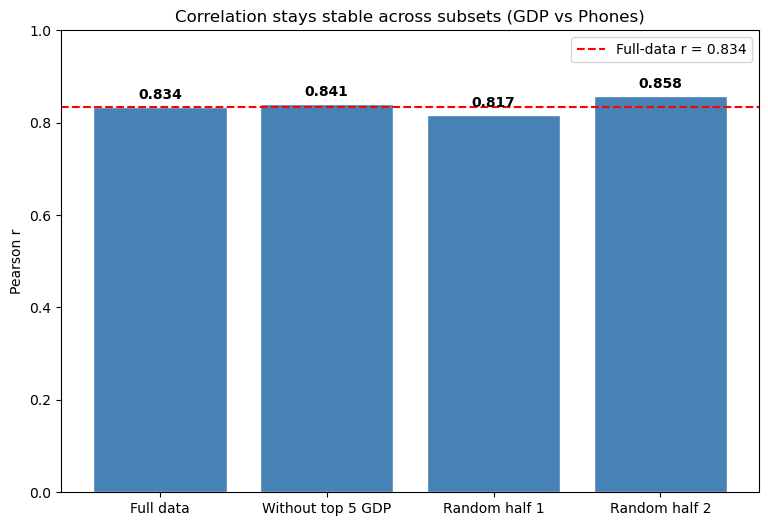

In [8]:
labels = ["Full data", "Without top 5 GDP", "Random half 1", "Random half 2"]
r_values = [0.834, 0.841, 0.817, 0.858]

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, r_values, color="steelblue", edgecolor="white")

# Value label on top of each bar
for bar, val in zip(bars, r_values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontweight="bold")

# Reference line at the full-data r
plt.axhline(0.834, color="red", linestyle="--", linewidth=1.5,
            label="Full-data r = 0.834")

plt.ylim(0, 1)
plt.ylabel("Pearson r")
plt.title("Correlation stays stable across subsets (GDP vs Phones)")
plt.legend()
plt.show()

Highest GDP per capita: Luxembourg = 55,100


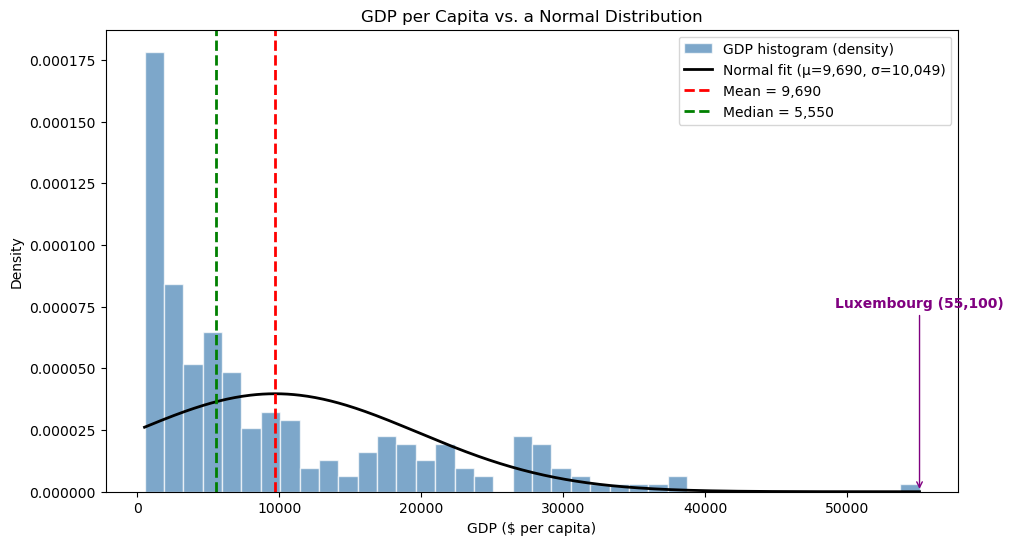

In [9]:
import numpy as np
from scipy.stats import norm

gdp = df["GDP ($ per capita)"].dropna()
mean_gdp = gdp.mean()
median_gdp = gdp.median()
std_gdp = gdp.std()

# 4. Country with the highest GDP per capita (biggest outlier)
top_idx = df["GDP ($ per capita)"].idxmax()
top_country = df.loc[top_idx, "Country"]
top_gdp = df.loc[top_idx, "GDP ($ per capita)"]
print(f"Highest GDP per capita: {top_country} = {top_gdp:,.0f}")

plt.figure(figsize=(11, 6))

# 1. Density histogram
plt.hist(gdp, bins=40, density=True, color="steelblue",
         edgecolor="white", alpha=0.7, label="GDP histogram (density)")

# 2. Fitted normal curve
x = np.linspace(gdp.min(), gdp.max(), 500)
plt.plot(x, norm.pdf(x, mean_gdp, std_gdp), color="black", linewidth=2,
         label=f"Normal fit (μ={mean_gdp:,.0f}, σ={std_gdp:,.0f})")

# 3. Mean and median lines
plt.axvline(mean_gdp, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {mean_gdp:,.0f}")
plt.axvline(median_gdp, color="green", linestyle="--", linewidth=2,
            label=f"Median = {median_gdp:,.0f}")

# 4. Annotate the biggest outlier
plt.annotate(f"{top_country} ({top_gdp:,.0f})",
             xy=(top_gdp, 0), xytext=(top_gdp, plt.ylim()[1] * 0.4),
             ha="center", color="purple", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="purple"))

plt.title("GDP per Capita vs. a Normal Distribution")
plt.xlabel("GDP ($ per capita)")
plt.ylabel("Density")
plt.legend()
plt.show()

Countries with |z| > 2:

       Country  GDP ($ per capita)  GDP_zscore
    Luxembourg             55100.0    4.518813
        Norway             37800.0    2.797272
 United States             37800.0    2.797272
       Bermuda             36000.0    2.618152
Cayman Islands             35000.0    2.518641
    San Marino             34600.0    2.478837
   Switzerland             32700.0    2.289766
       Denmark             31100.0    2.130549
       Iceland             30900.0    2.110646
       Austria             30000.0    2.021086
        Canada             29800.0    2.001184

Countries with |z| > 2: 11
Countries with |z| > 3: 1


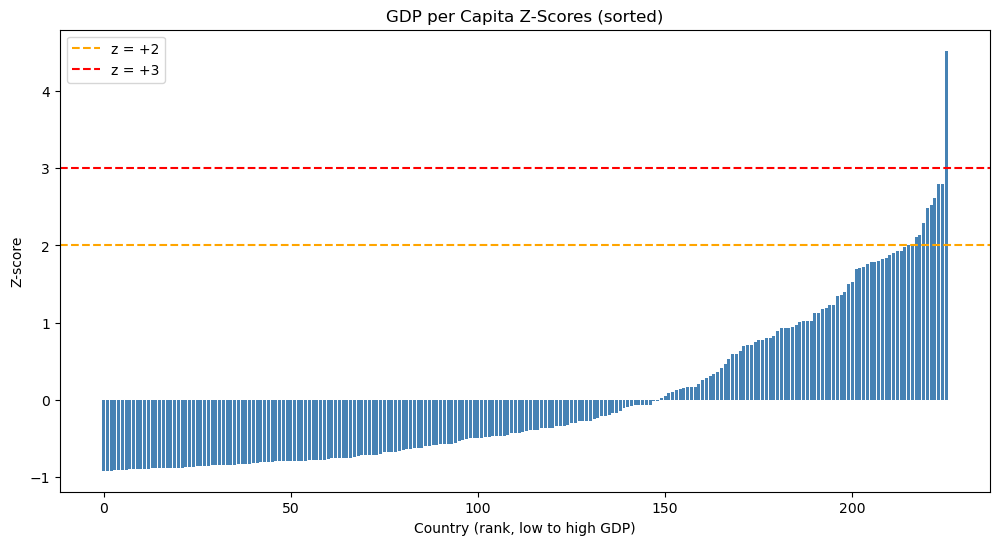

In [10]:
gdp = df["GDP ($ per capita)"]

# 1. Z-score column
df["GDP_zscore"] = (gdp - gdp.mean()) / gdp.std()

# 2. Countries with |z| > 2, sorted high to low
outliers = df[df["GDP_zscore"].abs() > 2].sort_values("GDP_zscore", ascending=False)
print("Countries with |z| > 2:\n")
print(outliers[["Country", "GDP ($ per capita)", "GDP_zscore"]].to_string(index=False))

# 3. Counts
print(f"\nCountries with |z| > 2: {(df['GDP_zscore'].abs() > 2).sum()}")
print(f"Countries with |z| > 3: {(df['GDP_zscore'].abs() > 3).sum()}")

# Bar chart of sorted z-scores
z_sorted = df["GDP_zscore"].dropna().sort_values().reset_index(drop=True)
plt.figure(figsize=(12, 6))
plt.bar(range(len(z_sorted)), z_sorted, color="steelblue")
plt.axhline(2, color="orange", linestyle="--", linewidth=1.5, label="z = +2")
plt.axhline(3, color="red", linestyle="--", linewidth=1.5, label="z = +3")
plt.title("GDP per Capita Z-Scores (sorted)")
plt.xlabel("Country (rank, low to high GDP)")
plt.ylabel("Z-score")
plt.legend()
plt.show()

Unweighted mean (per country): 9,690
Weighted mean   (per person):  8,080
Difference:                    1,610

6 most populous countries:
      Country  Population  GDP ($ per capita)
        China  1313973713              5000.0
        India  1095351995              2900.0
United States   298444215             37800.0
    Indonesia   245452739              3200.0
       Brazil   188078227              7600.0
     Pakistan   165803560              2100.0


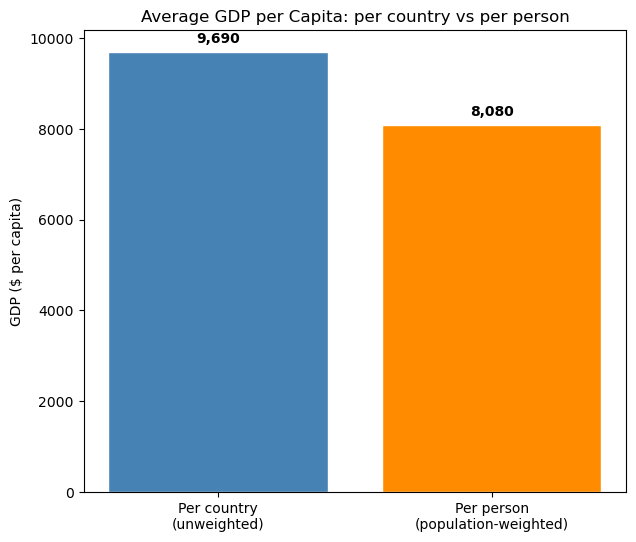

In [11]:
# 1. Simple unweighted mean (every country counts equally)
unweighted = df["GDP ($ per capita)"].mean()

# 2. Population-weighted mean (every person counts equally)
gw = df[["GDP ($ per capita)", "Population"]].dropna()
weighted = np.average(gw["GDP ($ per capita)"], weights=gw["Population"])

# 3. Side by side
print(f"Unweighted mean (per country): {unweighted:,.0f}")
print(f"Weighted mean   (per person):  {weighted:,.0f}")
print(f"Difference:                    {unweighted - weighted:,.0f}")

# 4. The 6 most populous countries and their GDP per capita
print("\n6 most populous countries:")
top_pop = df.sort_values("Population", ascending=False).head(6)
print(top_pop[["Country", "Population", "GDP ($ per capita)"]].to_string(index=False))

# Bar chart comparing the two
plt.figure(figsize=(7, 6))
bars = plt.bar(["Per country\n(unweighted)", "Per person\n(population-weighted)"],
               [unweighted, weighted], color=["steelblue", "darkorange"], edgecolor="white")
for bar, val in zip(bars, [unweighted, weighted]):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 150,
             f"{val:,.0f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("GDP ($ per capita)")
plt.title("Average GDP per Capita: per country vs per person")
plt.show()

True mean (all countries):        9,690
Rich regions only (W.Eur+N.Amer): 26,903
Sub-Saharan Africa only:          2,324

Countries left out of rich sample: 194 of 227
Share of world population left out: 88.8%


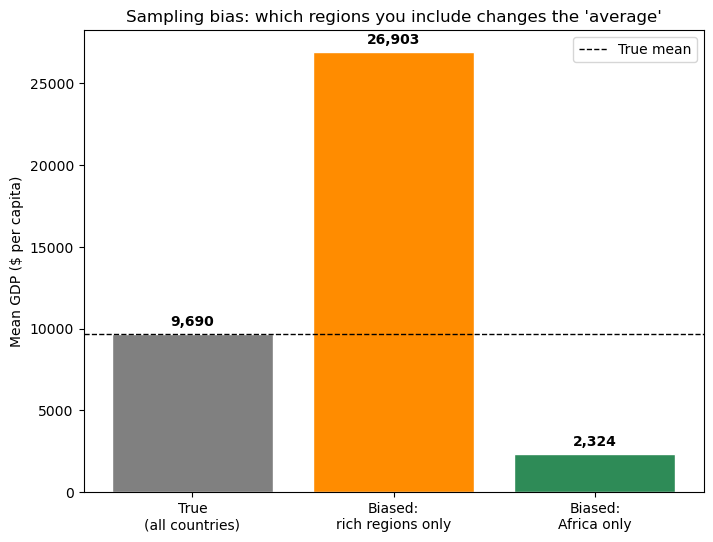

In [12]:
# 1. True mean across all countries
true_mean = df["GDP ($ per capita)"].mean()
print(f"True mean (all countries):        {true_mean:,.0f}")

# 2. Biased sample: rich regions only (Western Europe + Northern America)
rich = df[df["Region"].isin(["WESTERN EUROPE", "NORTHERN AMERICA"])]
rich_mean = rich["GDP ($ per capita)"].mean()
print(f"Rich regions only (W.Eur+N.Amer): {rich_mean:,.0f}")

# 3. Biased sample: Sub-Saharan Africa only
africa = df[df["Region"] == "SUB-SAHARAN AFRICA"]
africa_mean = africa["GDP ($ per capita)"].mean()
print(f"Sub-Saharan Africa only:          {africa_mean:,.0f}")

# 4. Who is left out of the rich-regions sample
left_out = df[~df["Region"].isin(["WESTERN EUROPE", "NORTHERN AMERICA"])]
total_pop = df["Population"].sum()
left_out_share = left_out["Population"].sum() / total_pop * 100
print(f"\nCountries left out of rich sample: {len(left_out)} of {len(df)}")
print(f"Share of world population left out: {left_out_share:.1f}%")

# 5. Bar chart comparing the three estimates
labels = ["True\n(all countries)", "Biased:\nrich regions only", "Biased:\nAfrica only"]
values = [true_mean, rich_mean, africa_mean]
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=["gray", "darkorange", "seagreen"], edgecolor="white")
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 300,
             f"{val:,.0f}", ha="center", va="bottom", fontweight="bold")
plt.axhline(true_mean, color="black", linestyle="--", linewidth=1, label="True mean")
plt.ylabel("Mean GDP ($ per capita)")
plt.title("Sampling bias: which regions you include changes the 'average'")
plt.legend()
plt.show()

=== Comparison A: WESTERN EUROPE vs SUB-SAHARAN AFRICA ===
  WESTERN EUROPE mean: 27,046  (n=28)
  SUB-SAHARAN AFRICA mean: 2,324  (n=51)
  Difference in means: 24,723
  t-statistic: 16.641
  p-value:     7.314e-17

=== Comparison B: ASIA (EX. NEAR EAST) vs OCEANIA ===
  ASIA (EX. NEAR EAST) mean: 8,054  (n=28)
  OCEANIA mean: 8,248  (n=21)
  Difference in means: -194
  t-statistic: -0.078
  p-value:     0.9378



/var/folders/xw/20s6937n15j4qt32krtk13_w0000gn/T/ipykernel_39977/2687423736.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([g1a, g2a], labels=["W. Europe", "Sub-Sah. Africa"])
/var/folders/xw/20s6937n15j4qt32krtk13_w0000gn/T/ipykernel_39977/2687423736.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([g1b, g2b], labels=["Asia (ex. Near East)", "Oceania"])


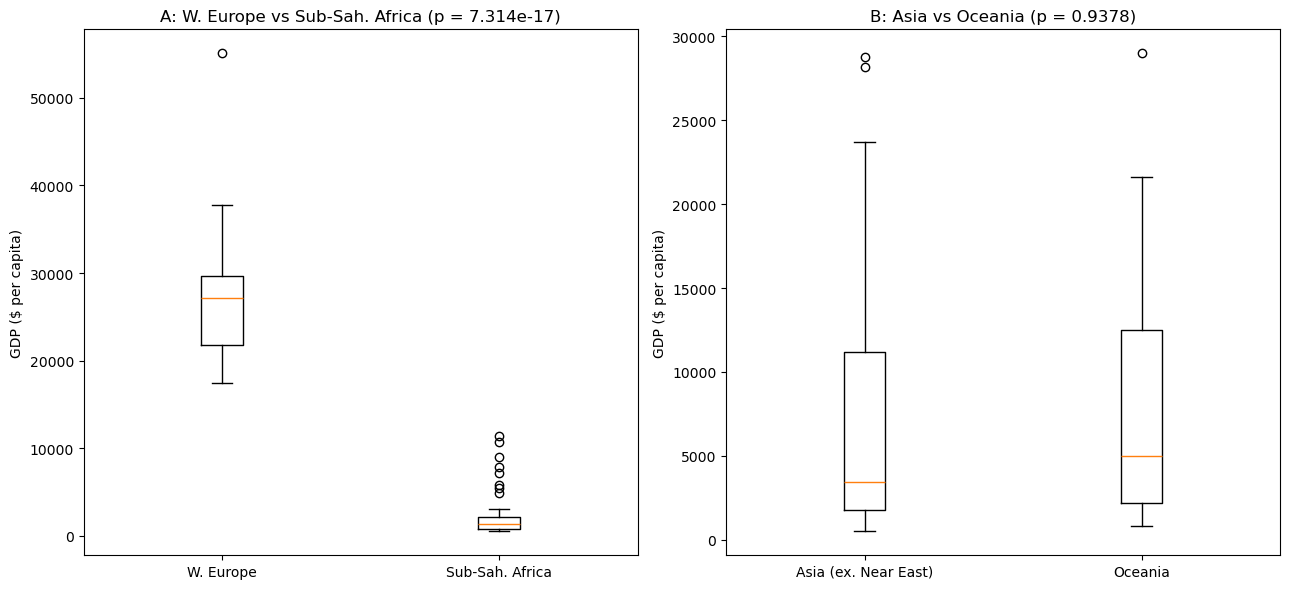

In [13]:
from scipy.stats import ttest_ind

def gdp_of(region):
    return df.loc[df["Region"] == region, "GDP ($ per capita)"].dropna()

def run_ttest(name, region1, region2):
    g1, g2 = gdp_of(region1), gdp_of(region2)
    t, p = ttest_ind(g1, g2, equal_var=False)
    print(f"=== Comparison {name}: {region1} vs {region2} ===")
    print(f"  {region1} mean: {g1.mean():,.0f}  (n={len(g1)})")
    print(f"  {region2} mean: {g2.mean():,.0f}  (n={len(g2)})")
    print(f"  Difference in means: {g1.mean() - g2.mean():,.0f}")
    print(f"  t-statistic: {t:.3f}")
    print(f"  p-value:     {p:.4g}\n")
    return g1, g2, p

g1a, g2a, pa = run_ttest("A", "WESTERN EUROPE", "SUB-SAHARAN AFRICA")
g1b, g2b, pb = run_ttest("B", "ASIA (EX. NEAR EAST)", "OCEANIA")

# Box plots, one subplot per comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].boxplot([g1a, g2a], labels=["W. Europe", "Sub-Sah. Africa"])
axes[0].set_title(f"A: W. Europe vs Sub-Sah. Africa (p = {pa:.4g})")
axes[0].set_ylabel("GDP ($ per capita)")

axes[1].boxplot([g1b, g2b], labels=["Asia (ex. Near East)", "Oceania"])
axes[1].set_title(f"B: Asia vs Oceania (p = {pb:.4g})")
axes[1].set_ylabel("GDP ($ per capita)")

plt.tight_layout()
plt.show()